<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-bottom: 2px solid #333; padding-bottom: 12px; margin-bottom: 20px;">
    <h1 style="margin: 0 0 6px 0; font-size: 24px; color: #111;">air-quality-neighborhoods.ipynb</h1>
    <div style="font-size: 13px; color: #555;">
        <span><strong>Project:</strong> NYC Air Quality Public Health Data Analysis</span> &nbsp;&bull;&nbsp; 
        <span><strong>Author:</strong> Kathryn Penrod</span> &nbsp;&bull;&nbsp; 
        <span><strong>Goal:</strong> Which neighborhoods are experiencing the highest environmental health burdens?</span>
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

data = pd.read_pickle('all_clean_dfs.pkl')
globals().update(data)
all_dfs = data

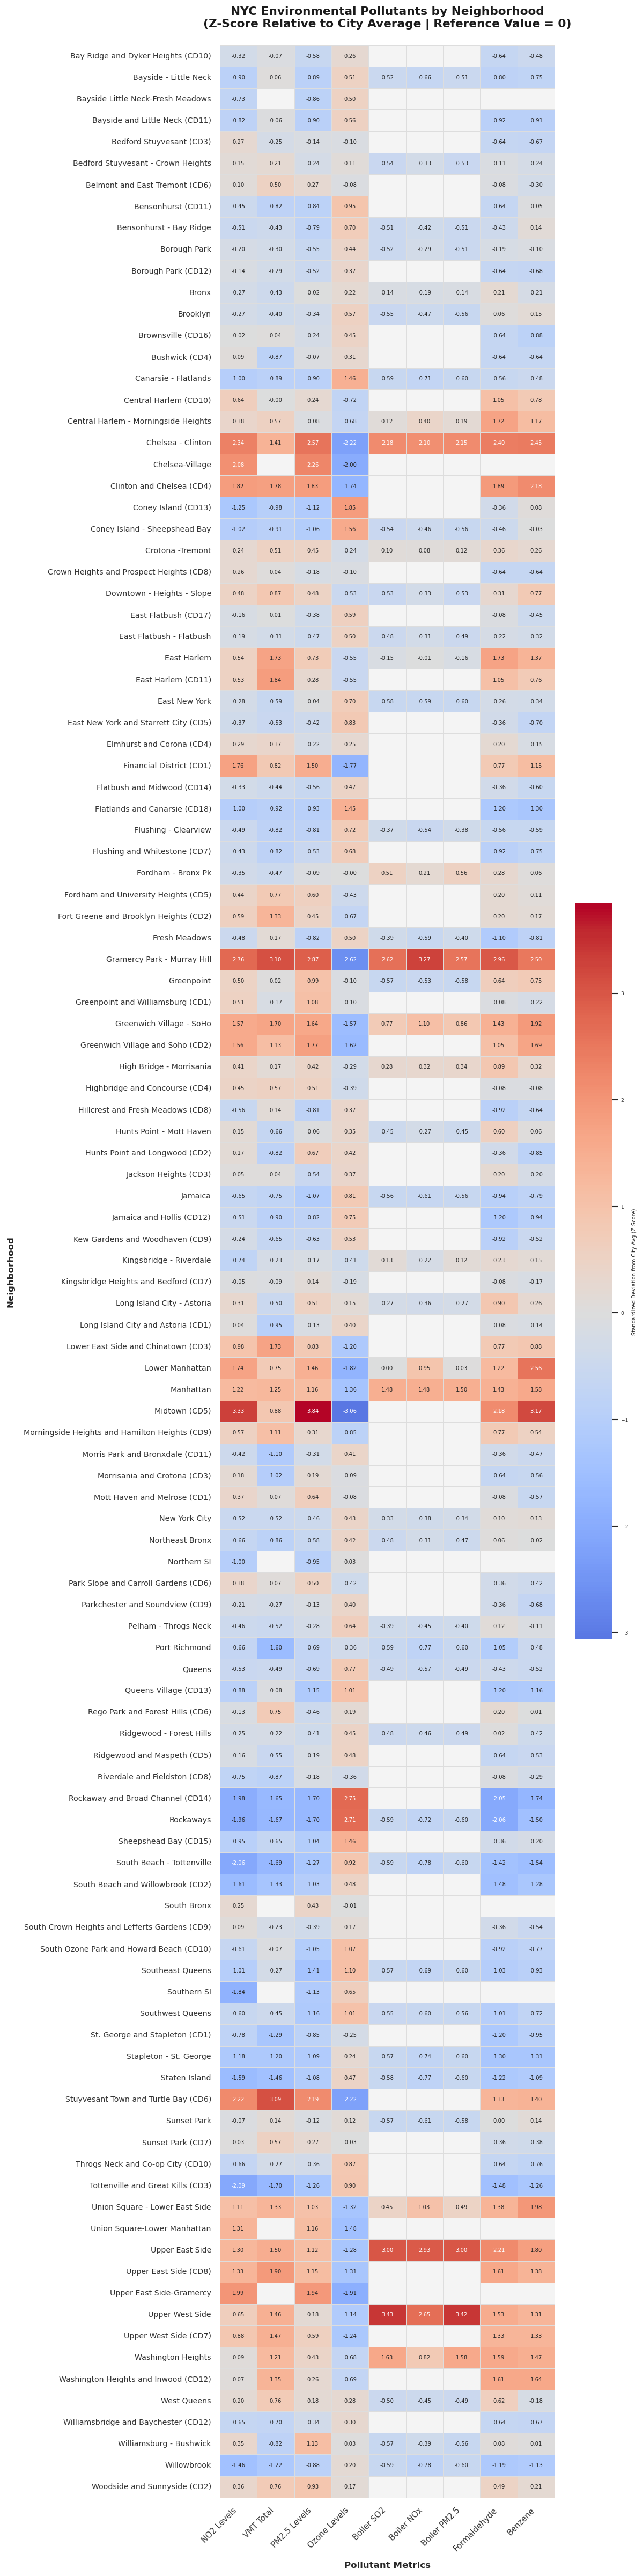

In [2]:
#heatmap of pollutants by location - comprehensive



#Standardize to Z-scores
matrix_zscore = pivoted_df.apply(lambda x: (x - x.mean()) / x.std())

#variables for the heatmap
selected_variables = [
    "NO2 Levels",
    "VMT Total",
    "PM2.5 Levels",
    "Ozone Levels",
    "Boiler SO2",
    "Boiler NOx",
    "Boiler PM2.5",
    "Formaldehyde",
    "Benzene",
]

# Filter to selected variables
matrix_subset = matrix_zscore[selected_variables]

# colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

#Plot Heatmap using 'matrix_subset'
plt.figure(figsize=(10, 40), dpi=120)
sns.set_theme(style="white", font_scale=0.5)

ax = sns.heatmap(
    matrix_subset, 
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Deviation from City Avg (Z-Score)",
        "shrink": 0.3,},)

#Titles & format
plt.title(
    "NYC Environmental Pollutants by Neighborhood\n(Z-Score Relative to City"
    " Average | Reference Value = 0)",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

plt.xlabel("Pollutant Metrics", fontsize=10, fontweight="bold", labelpad=10)
plt.ylabel("Neighborhood", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=8.5, color="#333333")

plt.tight_layout()
plt.show()

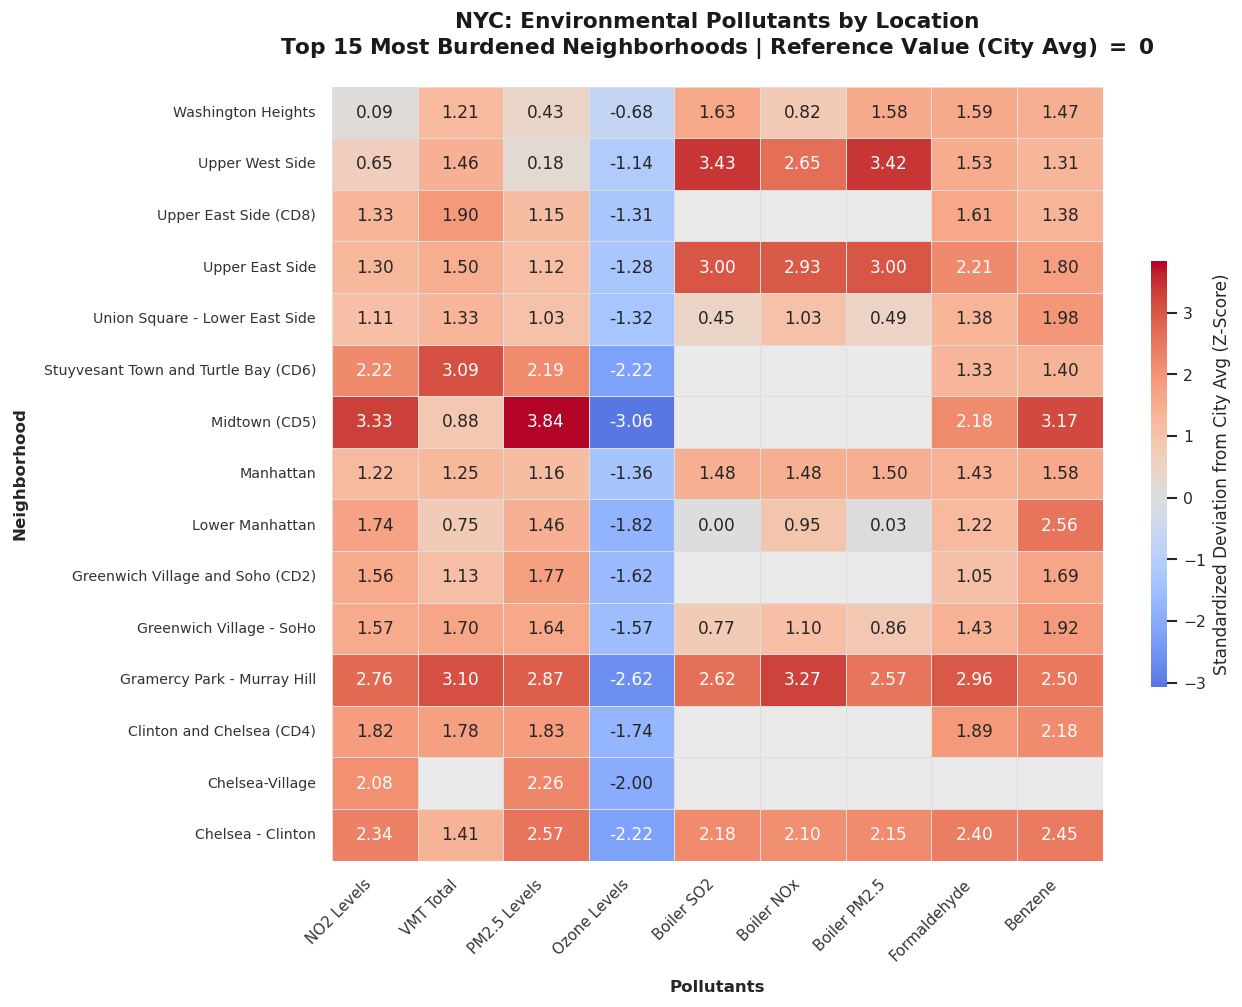

In [3]:
#heatmap - Environmental Pollutants by Location Top 15 


#variables
selected_variables = [
    "NO2 Levels",
    "VMT Total",
    "PM2.5 Levels",
    "Ozone Levels",
    "Boiler SO2",
    "Boiler NOx",
    "Boiler PM2.5",
    "Formaldehyde",
    "Benzene",
]

#make float
temp_subset = pivoted_df[selected_variables].apply(
    pd.to_numeric, errors="coerce"
)

#Standardize to Z-scores (0 = City Avg)
pollu_zscore = temp_subset.apply(lambda x: (x - x.mean()) / x.std())

# Calculate overall burden and filter to top 15 locations
pollu_zscore["overall_burden"] = pollu_zscore.mean(axis=1)
top_15_locations = (
    pollu_zscore.nlargest(15, "overall_burden")
    .drop(columns=["overall_burden"])
    .sort_index(ascending=False)
)

# formatting
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#EAEAEA")

plt.figure(figsize=(11, 8.5), dpi=120)
sns.set_theme(style="white", font_scale=0.85)

ax = sns.heatmap(
    top_15_locations,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Deviation from City Avg (Z-Score)",
        "shrink": 0.55,
        "aspect": 26,
    },
)

plt.title(
    "NYC: Environmental Pollutants by Location\n"
    r"$\bf{Top\ 15\ Most\ Burdened\ Neighborhoods\ |\ Reference\ Value\ (City\ Avg)\ =\ 0}$",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

plt.xlabel("Pollutants", fontsize=10, fontweight="bold", labelpad=10)
plt.ylabel("Neighborhood", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=8.5, color="#333333")

plt.tight_layout()
plt.show()

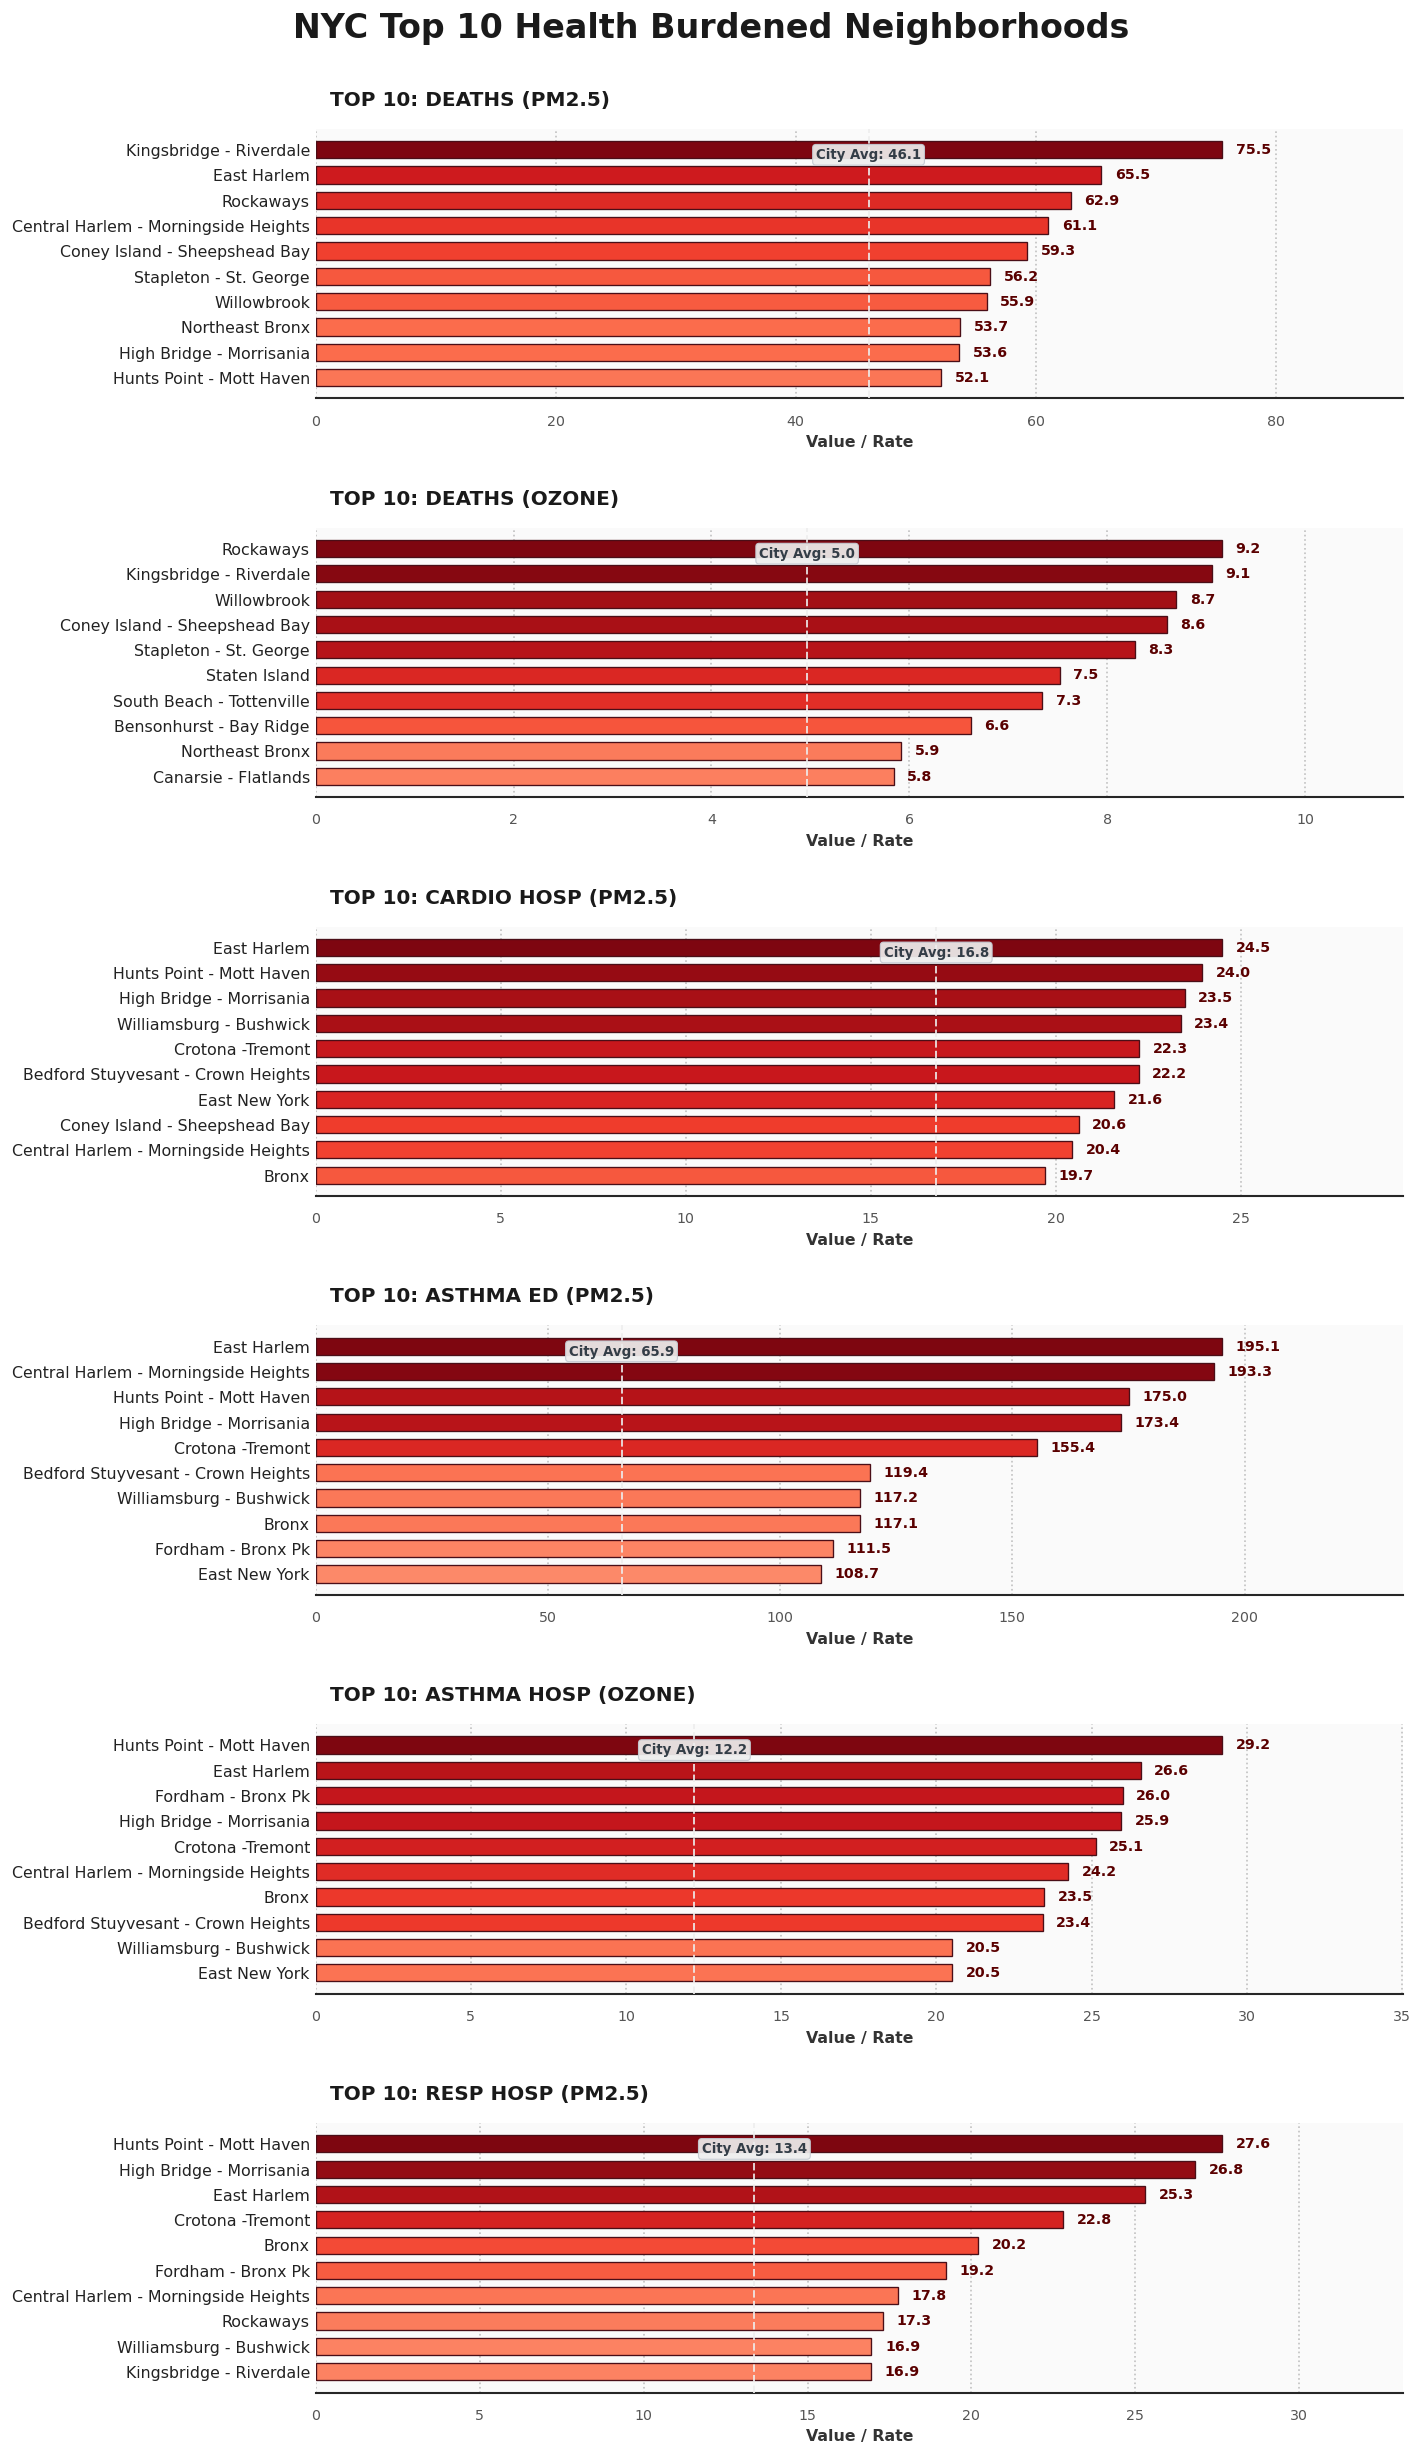

In [4]:
#bar chart - Top 10 Health Burdened Neighborhoods - separate visual for each health variable


sns.set_theme(style="white", font_scale=0.95)

#variables
health_metrics = [
    "Deaths (PM2.5)",
    "Deaths (Ozone)",
    "Cardio Hosp (PM2.5)",
    "Asthma ED (PM2.5)",
    "Asthma Hosp (Ozone)",
    "Resp Hosp (PM2.5)",
]

#pivoted df metrics only
valid_metrics = [m for m in health_metrics if m in pivoted_df.columns]

# Grid setup
fig, axes = plt.subplots(
    len(valid_metrics), 1, figsize=(12, 3.4 * len(valid_metrics)), dpi=120
)
if len(valid_metrics) == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Loop through variables
for i, metric_name in enumerate(valid_metrics):
    ax = axes[i]

    # FIX: Reset index so 'Geo Place Name' is a normal column we can grab
    df_clean = pivoted_df.reset_index()[
        ["Geo Place Name", metric_name]
    ].dropna()

    if df_clean.empty:
        continue

    val_col = metric_name

    # Compute citywide average
    city_avg = df_clean[val_col].mean()

    # Get Top 10 sorted ascending for horizontal layout
    top_10 = df_clean.nlargest(10, val_col).sort_values(
        by=val_col, ascending=True
    )

    # Colormap 
    values = top_10[val_col].values
    norm = mcolors.Normalize(vmin=values.min() * 0.85, vmax=values.max())
    colormap = plt.get_cmap("Reds")
    bar_colors = [colormap(0.30 + 0.65 * norm(v)) for v in values]

    # Plot horizontal bars
    bars = ax.barh(
        top_10["Geo Place Name"],
        top_10[val_col],
        color=bar_colors,
        edgecolor="#4A0E17",
        linewidth=0.8,
        height=0.68,
        zorder=3,
    )

    # Styling & Gridlines
    ax.set_facecolor("#FAFAFA")
    ax.grid(True, linestyle=":", alpha=0.5, color="#888888", axis="x", zorder=0)
    sns.despine(top=True, right=True, left=True, bottom=False, ax=ax)

    # Subplot Header
    ax.set_title(
        f"  TOP 10: {metric_name.upper()}  ",
        fontsize=12,
        fontweight="bold",
        pad=14,
        loc="left",
        color="#1A1A1A",
    )

    # axis labels
    ax.set_xlabel(
        "Value / Rate", fontsize=9.5, fontweight="bold", color="#333333"
    )
    ax.tick_params(axis="y", labelsize=9.5, colors="#222222", length=0)
    ax.tick_params(axis="x", labelsize=8.5, colors="#555555")

    # Numeric End Badges on Bars
    max_val = top_10[val_col].max()
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + (max_val * 0.015),
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.1f}",
            ha="left",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color="#5A0000",
        )

    # City average line
    ax.axvline(
        x=city_avg,
        color="#eeeeee",
        linestyle="--",
        linewidth=1.2,
        alpha=0.85,
        zorder=5,
    )

    # City average box
    ax.text(
        city_avg,
        8.8,
        f"City Avg: {city_avg:,.1f}",
        color="#333D47",
        fontsize=8,
        fontweight="bold",
        va="center",
        ha="center",
        zorder=7,
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="#eeeeee",
            edgecolor="#C5CBD3",
            linewidth=0.7,
            alpha=0.92,
        ),
    )

    # Scale X limit to accommodate bars and labels
    ax.set_xlim(0, max(max_val, city_avg) * 1.20)

# Title Banner
plt.suptitle(
    "NYC Top 10 Health Burdened Neighborhoods",
    fontsize=20,
    fontweight="bold",
    color="#1A1A1A",
    y=1.002,
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.48)
plt.show()

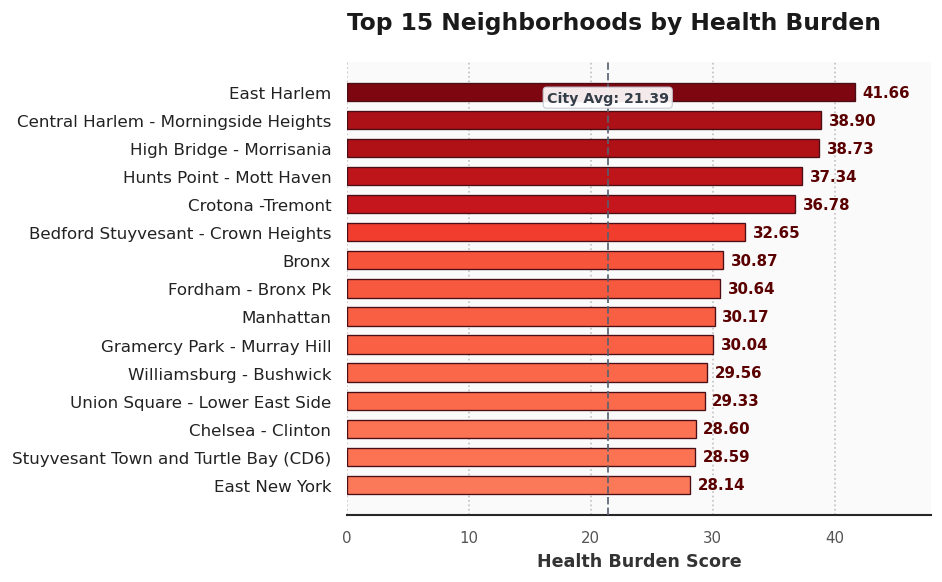

In [5]:
#bar chart - Top 15 Neighborhoods by Health Burden


sns.set_theme(style="white", font_scale=0.95)

# Use 'all_dfs'
valid_dfs = [v for v in all_dfs.values() if isinstance(v, pd.DataFrame)]

if valid_dfs:
    master_df = pd.concat(valid_dfs, ignore_index=True)

    # Detect metric value column
    val_col = next(
        (
            col
            for col in [
                "Data Value",
                "Value",
                "Estimated Annual Rate per 100,000",
                "Mean",
            ]
            if col in master_df.columns
        ),
        None,
    )

    if not val_col or "Geo Place Name" not in master_df.columns:
        raise KeyError(
            "Could not find required columns ('Geo Place Name' and value columns)."
        )


    if "composite_health_burden" not in master_df.columns:
        neighborhood_summary = (
            master_df.groupby("Geo Place Name")[val_col]
            .mean()
            .reset_index()
        )
        neighborhood_summary.columns = [
            "neighborhood",
            "health_burden_score",
        ]
    else:
        neighborhood_summary = (
            master_df[["Geo Place Name", "composite_health_burden"]]
            .drop_duplicates(subset=["Geo Place Name"])
            .copy()
        )
        neighborhood_summary = neighborhood_summary.rename(
            columns={
                "Geo Place Name": "neighborhood",
                "composite_health_burden": "health_burden_score",
            }
        )
else:
    raise ValueError("No valid pandas DataFrames found in `all_dfs`!")

# Compute Citywide Average
city_avg = neighborhood_summary["health_burden_score"].mean()

# Extract Top 15 sorted ascending
top_15 = neighborhood_summary.nlargest(
    15, "health_burden_score"
).sort_values(by="health_burden_score", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

# Red Colormap Gradient
scores = top_15["health_burden_score"].values
norm = mcolors.Normalize(vmin=scores.min() * 0.85, vmax=scores.max())
colormap = plt.get_cmap("Reds")
bar_colors = [colormap(0.30 + 0.65 * norm(s)) for s in scores]

# Plot Horizontal Bars
bars = ax.barh(
    top_15["neighborhood"],
    top_15["health_burden_score"],
    color=bar_colors,
    edgecolor="#4A0E17",
    linewidth=0.8,
    height=0.65,
    zorder=3,
)

# Background & gridlines
ax.set_facecolor("#FAFAFA")
ax.grid(True, linestyle=":", alpha=0.5, color="#888888", axis="x", zorder=0)
sns.despine(top=True, right=True, left=True, bottom=False, ax=ax)

# Title & styling
ax.set_title(
    "Top 15 Neighborhoods by Health Burden",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="left",
    color="#1A1A1A",
)

ax.set_xlabel(
    "Health Burden Score",
    fontsize=10.5,
    fontweight="bold",
    color="#333333",
)
ax.tick_params(axis="y", labelsize=10, colors="#222222")
ax.tick_params(axis="x", labelsize=9, colors="#555555")

# Value Badges at end of bars
max_val = top_15["health_burden_score"].max()
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max_val * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.2f}",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#5A0000",
    )

# appearance
ax.axvline(
    x=city_avg,
    color="#55606E",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    zorder=5,
)


ax.text(
    city_avg,
    13.8,
    f"City Avg: {city_avg:,.2f}",
    color="#333D47",
    fontsize=8.5,
    fontweight="bold",
    va="center",
    ha="center",
    zorder=7,
    clip_on=False,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="#FFFFFF",
        edgecolor="#C5CBD3",
        linewidth=0.7,
        alpha=0.92,
    ),
)

ax.set_xlim(0, max(max_val, city_avg) * 1.15)
plt.tight_layout()
plt.show()

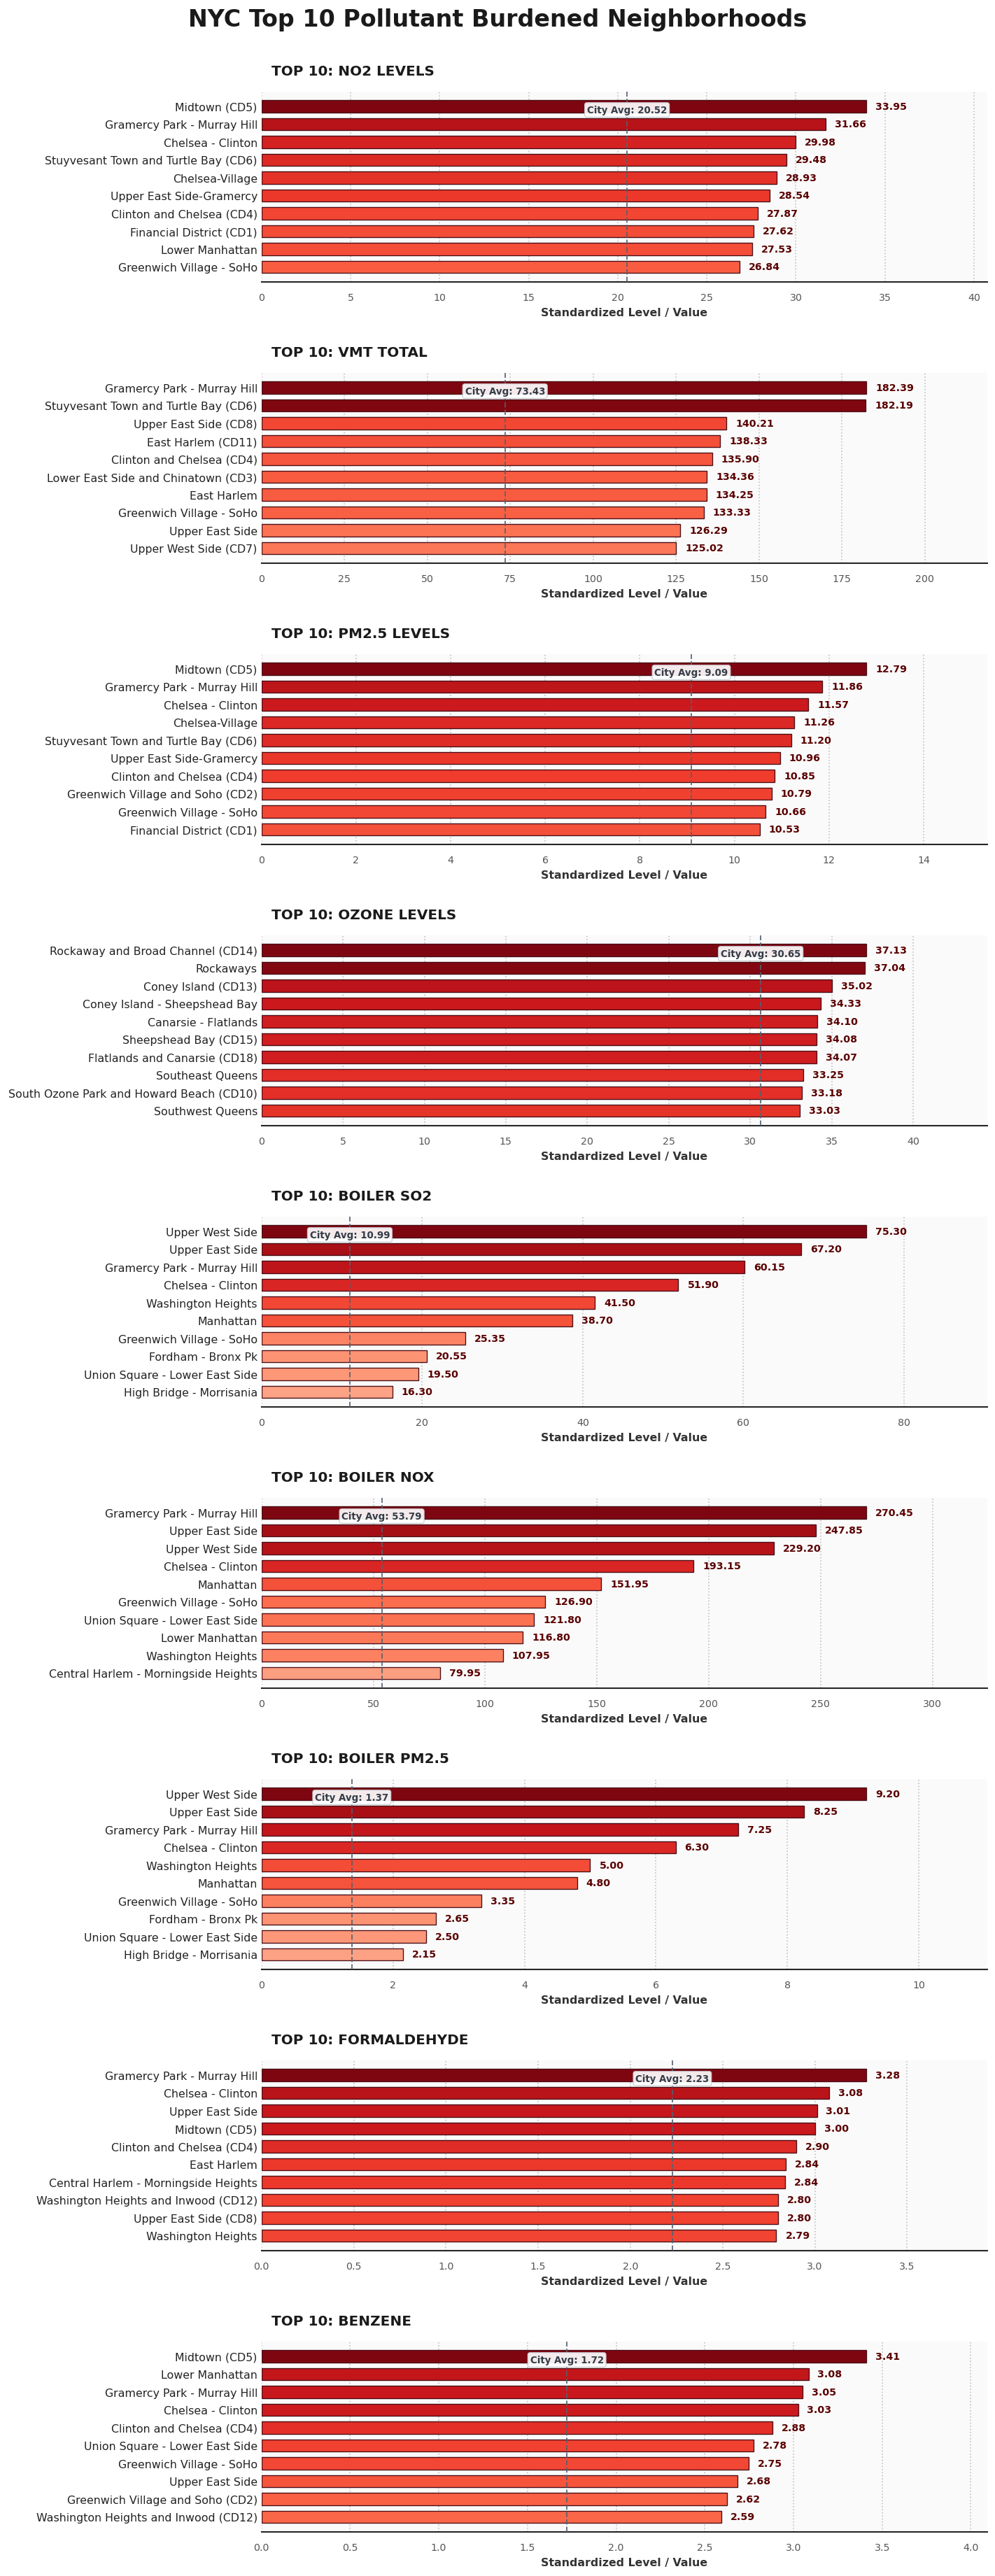

In [6]:
#bar chart - Top 10 Pollutant Burdened Neighborhoods - separate visual for each pollutant


sns.set_theme(style="white", font_scale=0.95)

# variables
pollutant_metrics = [
    "NO2 Levels",
    "VMT Total",
    "PM2.5 Levels",
    "Ozone Levels",
    "Boiler SO2",
    "Boiler NOx",
    "Boiler PM2.5",
    "Formaldehyde",
    "Benzene",
]

# Filter  to only metrics that exist in pivoted_df
valid_metrics = [m for m in pollutant_metrics if m in pivoted_df.columns]

# Grid setup
num_metrics = len(valid_metrics)
num_rows = num_metrics if num_metrics > 0 else 1

fig, axes = plt.subplots(num_rows, 1, figsize=(12, 3.4 * num_rows), dpi=120)

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
axes = axes.flatten()

# Loop through variables
for i, metric_name in enumerate(valid_metrics):
    if i >= len(axes):
        break

    ax = axes[i]

    # Extract clean subset from pivoted_df
    df_clean = pivoted_df.reset_index()[
        ["Geo Place Name", metric_name]
    ].dropna()

    if df_clean.empty:
        continue

    val_col = metric_name

    # Compute citywide average
    city_avg = df_clean[val_col].mean()

    # Get Top 10 sorted ascending for horizontal layout
    top_10 = df_clean.nlargest(10, val_col).sort_values(
        by=val_col, ascending=True
    )

    # Colormap
    values = top_10[val_col].values
    norm = mcolors.Normalize(vmin=values.min() * 0.85, vmax=values.max())
    colormap = plt.get_cmap("Reds")
    bar_colors = [colormap(0.30 + 0.65 * norm(v)) for v in values]

    # Plot horizontal bars
    bars = ax.barh(
        top_10["Geo Place Name"],
        top_10[val_col],
        color=bar_colors,
        edgecolor="#4A0E17",
        linewidth=0.8,
        height=0.68,
        zorder=3,
    )

    # Styling & Gridlines
    ax.set_facecolor("#FAFAFA")
    ax.grid(True, linestyle=":", alpha=0.5, color="#888888", axis="x", zorder=0)
    sns.despine(top=True, right=True, left=True, bottom=False, ax=ax)

    # Subplot Header
    ax.set_title(
        f"  TOP 10: {metric_name.upper()}  ",
        fontsize=12,
        fontweight="bold",
        pad=14,
        loc="left",
        color="#1A1A1A",
    )

    # X-axis label
    ax.set_xlabel(
        "Standardized Level / Value",
        fontsize=9.5,
        fontweight="bold",
        color="#333333",
    )

    ax.tick_params(axis="y", labelsize=9.5, colors="#222222", length=0)
    ax.tick_params(axis="x", labelsize=8.5, colors="#555555")

    # Numeric End Badges on Bars
    max_val = top_10[val_col].max()
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + (max_val * 0.015),
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            ha="left",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color="#5A0000",
        )

    # City average line
    ax.axvline(
        x=city_avg,
        color="#55606E",
        linestyle="--",
        linewidth=1.2,
        alpha=0.85,
        zorder=5,
    )

    # City average box
    ax.text(
        city_avg,
        8.8,
        f"City Avg: {city_avg:,.2f}",
        color="#333D47",
        fontsize=8,
        fontweight="bold",
        va="center",
        ha="center",
        zorder=7,
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="#FFFFFF",
            edgecolor="#C5CBD3",
            linewidth=0.7,
            alpha=0.92,
        ),
    )

    # Scale X limit to accommodate bars and labels
    ax.set_xlim(0, max(max_val, city_avg) * 1.20)

# Remove unused subplots
for j in range(len(valid_metrics), len(axes)):
    fig.delaxes(axes[j])

# Title Banner
plt.suptitle(
    "NYC Top 10 Pollutant Burdened Neighborhoods",
    fontsize=20,
    fontweight="bold",
    color="#1A1A1A",
    y=1.002,
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.48)
plt.show()

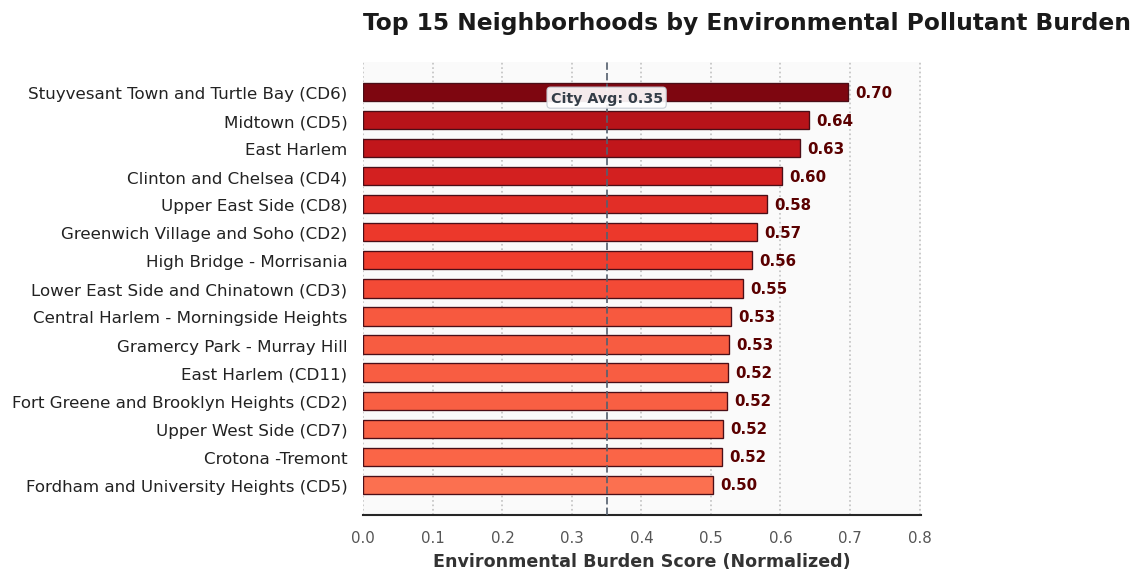

In [7]:
#bar chart - Top 15 Neighborhoods by Environmental Pollutant Burden


# Combine dfs
valid_dfs = []
for key, df in all_dfs.items():
    if isinstance(df, pd.DataFrame):
        df_temp = df.copy()
        df_temp["source_indicator"] = key
        valid_dfs.append(df_temp)

master_df = pd.concat(valid_dfs, ignore_index=True)

# Identify the value column
val_col = next(
    (col for col in ["Data Value", "Value", "Mean"] if col in master_df.columns),
    None,
)

#Get mean value per neighborhood per indicator
indicator_means = (
        master_df.groupby(["Geo Place Name", "source_indicator"])[val_col]
        .mean()
        .reset_index()
    )
    
    #Min-Max normalize each indicator source to prevent scale bias
min_v = indicator_means.groupby("source_indicator")[val_col].transform("min")
max_v = indicator_means.groupby("source_indicator")[val_col].transform("max")
range_v = max_v - min_v
    
indicator_means["normalized_val"] = np.where(
        range_v == 0, 
        0.0, 
        (indicator_means[val_col] - min_v) / range_v
    )
    
    #Average the normalized scores across all indicators per neighborhood
composite_summary = (
        indicator_means.groupby("Geo Place Name")["normalized_val"]
        .mean()
        .reset_index()
        .rename(columns={"Geo Place Name": "Geo Place Name", "normalized_val": "composite_health_burden"})
    )
    
    # Merge back master_df
master_df = master_df.merge(composite_summary, on="Geo Place Name", how="left", suffixes=("", "_computed"))
if "composite_health_burden_computed" in master_df.columns:
    master_df["composite_health_burden"] = master_df["composite_health_burden_computed"]
    master_df.drop(columns=["composite_health_burden_computed"], inplace=True)

# neighborhood summary 
neighborhood_summary = (
    master_df[["Geo Place Name", "composite_health_burden"]]
    .drop_duplicates(subset=["Geo Place Name"])
    .copy()
)

neighborhood_summary = neighborhood_summary.rename(
    columns={
        "Geo Place Name": "neighborhood",
        "composite_health_burden": "environmental_burden_score",
    }
)

sns.set_theme(style="white", font_scale=0.95)

# Compute Citywide Average Baseline
city_avg = neighborhood_summary["environmental_burden_score"].mean()

# Extract Top 15 
top_15 = neighborhood_summary.nlargest(
    15, "environmental_burden_score"
).sort_values(by="environmental_burden_score", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

# Red Colormap Gradient
scores = top_15["environmental_burden_score"].values

# Gradient bars
norm = mcolors.Normalize(vmin=scores.min() * 0.85, vmax=scores.max())
colormap = plt.get_cmap("Reds")
bar_colors = [colormap(0.30 + 0.65 * norm(s)) for s in scores]

# Plot Horizontal Bars
bars = ax.barh(
    top_15["neighborhood"],
    top_15["environmental_burden_score"],
    color=bar_colors,
    edgecolor="#4A0E17",  # Dark crimson border around each bar
    linewidth=0.8,
    height=0.65,
    zorder=3,
)

# Background & gridlines
ax.set_facecolor("#FAFAFA")
ax.grid(True, linestyle=":", alpha=0.5, color="#888888", axis="x", zorder=0)

sns.despine(top=True, right=True, left=True, bottom=False, ax=ax)

# Title & styling
ax.set_title(
    "Top 15 Neighborhoods by Environmental Pollutant Burden",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="left",
    color="#1A1A1A",
)

ax.set_xlabel(
    "Environmental Burden Score (Normalized)",
    fontsize=10.5,
    fontweight="bold",
    color="#333333",
)
ax.tick_params(axis="y", labelsize=10, colors="#222222")
ax.tick_params(axis="x", labelsize=9, colors="#555555")

# Value Badges at end of bars
max_val = top_15["environmental_burden_score"].max()
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max_val * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.2f}",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#5A0000",
    )

# City Average Line
ax.axvline(
    x=city_avg,
    color="#55606E",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    zorder=5,
)

# badge & text
ax.text(
    city_avg,
    13.8,  # Sits right above the top bar (index 14)
    f"City Avg: {city_avg:,.2f}",
    color="#333D47",
    fontsize=8.5,
    fontweight="bold",
    va="center",
    ha="center",
    zorder=7,
    clip_on=False,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="#FFFFFF",
        edgecolor="#C5CBD3",
        linewidth=0.7,
        alpha=0.92,
    ),
)

# Adjust X-axis limit to accommodate bars, badges, and line
ax.set_xlim(0, max(max_val, city_avg) * 1.15)

plt.tight_layout()
plt.show()